In [2]:
import torch
import matplotlib.pyplot as plt
import argparse
# from config.config import default_config as config

In [3]:
# --- Configuration ---

# # Define vocabulary size and transformer configuration (3 Billion)
# VOCAB_SIZE = 50304          # Number of unique tokens in the vocabulary
# CONTEXT_LENGTH = 512        # Maximum sequence length for the model
# N_EMBED = 2048              # Dimension of the embedding space
# N_HEAD = 16                 # Number of attention heads in each transformer block
# N_BLOCKS = 64               # Number of transformer blocks in the model

# # Define vocabulary size and transformer configuration (0.8 Billion)
# VOCAB_SIZE = 50304           # Number of unique tokens in the vocabulary
# CONTEXT_LENGTH = 128         # Maximum sequence length for the model
# N_EMBED = 128               # Dimension of the embedding space
# N_HEAD = 8                  # Number of attention heads in each transformer block
# N_BLOCKS = 1                 # Number of transformer blocks in the model

# Define vocabulary size and transformer configuration (0.8 Billion)
VOCAB_SIZE = 50304           # Number of unique tokens in the vocabulary
CONTEXT_LENGTH = 128         # Maximum sequence length for the model
N_EMBED = 1024               # Dimension of the embedding space
N_HEAD = 16                  # Number of attention heads in each transformer block
N_BLOCKS = 12                # Number of transformer blocks in the model


# Paths to training and development datasets
TRAIN_PATH = "data/train/pile_train.h5"  # File path for the training dataset
DEV_PATH = "data/val/pile_dev.h5"      # File path for the validation dataset

# Transformer training parameters
T_BATCH_SIZE = 32          # Number of samples per training batch
T_GRAD_ACCUM_STEP = 16     # Gradient Accumlation Steps
T_CONTEXT_LENGTH = 16      # Context length for training batches
T_TRAIN_STEPS = 500000     # Total number of training steps
T_EVAL_STEPS = 1000        # Frequency (in steps) to perform evaluation
T_EVAL_ITERS = 250         # Number of iterations to evaluate the model
T_LR_DECAY_STEP = 50000    # Step at which to decay the learning rate
T_LR = 5e-4                # Initial learning rate for training
T_LR_DECAYED = 5e-5        # Learning rate after decay
T_LR_DECAY_WEIGHT = 0.1    # Learning rate decay weight
T_OUT_PATH = "models/transformer_200M.pt"  # Path to save the trained model

# Device configuration
DEVICE = 'cuda'

# Store all configurations in a dictionary for easy access and modification
default_config = {
    'vocab_size': VOCAB_SIZE,
    'context_length': CONTEXT_LENGTH,
    'n_embed': N_EMBED,
    'n_head': N_HEAD,
    'n_blocks': N_BLOCKS,
    'train_path': TRAIN_PATH,
    'dev_path': DEV_PATH,
    't_batch_size': T_BATCH_SIZE,
    't_grad_accum_steps': T_GRAD_ACCUM_STEP,
    't_context_length': T_CONTEXT_LENGTH,
    't_train_steps': T_TRAIN_STEPS,
    't_eval_steps': T_EVAL_STEPS,
    't_eval_iters': T_EVAL_ITERS,
    't_lr_decay_step': T_LR_DECAY_STEP,
    't_lr': T_LR,
    't_lr_decayed': T_LR_DECAYED,
    't_lr_decay_weight': T_LR_DECAY_WEIGHT,
    't_out_path': T_OUT_PATH,
    'device': DEVICE,
}


244874496
tensor(3.9242, device='cuda:0')


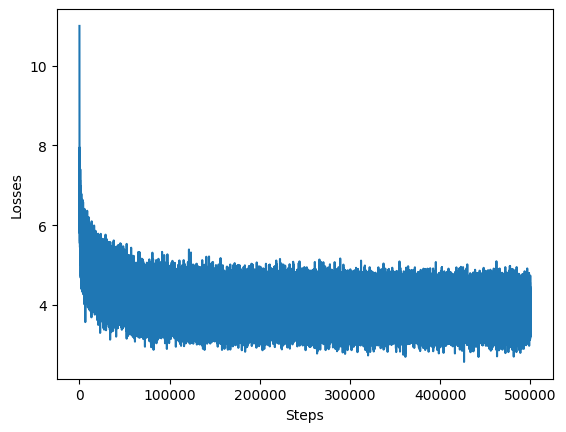

In [ ]:
def visualize_result(model_path: str,device):
    checkpoint = torch.load(model_path, map_location=torch.device(device))
    # number_pars = sum(p.numel() for p in checkpoint['model'].parameters())
    print(sum(p.numel() for p in checkpoint['model_state_dict'].values()))
    losses = checkpoint['losses']
    steps = checkpoint['steps']

    train_loss = checkpoint['train_loss']
    dev_loss = checkpoint['dev_loss']


    plt.plot(range(steps),losses)

    plt.xlabel("Steps")
    plt.ylabel("Losses")
    plt.show()

    # plt.plot(range(len(train_loss)),train_loss)

graph = visualize_result("../models/transformer_200M_1.pt",default_config['device'])